In [2]:
import nibabel as nib
import numpy as np
import math
from helper import normalized_modality, format_index, get_filepath, pad_to_256
from torch.utils.data import random_split, DataLoader, Dataset
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn 
import torch
import os
from pathlib import Path
from dotenv import dotenv_values, find_dotenv

config = dotenv_values(find_dotenv(usecwd=True))
TR_DATA_PATH = Path(config.get("TR_DATA_PATH"))

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, path):
        super().__init__()
        self.path = path
        self.dirnames = [d for d in Path(path).iterdir() if d.is_dir()]
        self.len = len(self.dirnames) # 369 brains
        self.slices = 155 # slices per brain

    def __len__(self):
        return self.len
    
    def get_path(self, brain_index, mod):
        brain_index += 1
        return get_filepath(brain_index, mod)
    
    def get_brain_mod(self, index, mod):
        path = self.get_path(index, mod)
        img = nib.load(path)
        brain = torch.tensor(img.get_fdata(), dtype=torch.float32)
        brain = brain.permute(2, 0, 1)

        if mod != "seg":
            brain = normalized_modality(brain)
            brain = pad_to_256(brain)   
            brain = brain.unsqueeze(1)
        
        if mod == "seg":
            brain[brain == 4] = 3
            brain = pad_to_256(brain)   
            brain = brain.to(torch.int64)

        return brain
            
    def __getitem__(self, index):
        # t1 = self.get_brain_mod(index, "t1")
        t1ce = self.get_brain_mod(index, "t1ce")
        # t2 = self.get_brain_mod(index, "t2")
        # flair = self.get_brain_mod(index, "flair")
        seg = self.get_brain_mod(index, "seg")
        brain = t1ce
        return brain, seg
        

In [ ]:
train_dataset = CustomDataset(TR_DATA_PATH)

train_size = int(len(train_dataset) * 0.9)
val_size = len(train_dataset) - train_size

train_sub, val_sub = random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_sub, batch_size=None, shuffle=True)

val_loader = DataLoader(val_sub, batch_size=None, shuffle=False)

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += y.numel()

    return total_loss / total_samples, total_correct / total_samples

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        step = 20
        for i in range(0, x.shape[0], step):
            xb = x[i:i+step].to(device)
            yb = y[i:i+step].to(device)
                
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_samples += yb.numel()

    return total_loss / total_samples, total_correct / total_samples

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # encoding
        self.econv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.econv2 = nn.Conv2d(32, 32, 3, padding=1)
        
        self.econv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.econv4 = nn.Conv2d(64, 64, 3, padding=1)
        self.max2 = nn.MaxPool2d(2, 2)
        
        self.econv5 = nn.Conv2d(64, 128, 3, padding=1)
        self.econv6 = nn.Conv2d(128, 128, 3, padding=1)
        self.max3 = nn.MaxPool2d(2, 2)
        
        self.econv7 = nn.Conv2d(128, 256, 3, padding=1)
        self.econv8 = nn.Conv2d(256, 256, 3, padding=1)

        self.econv9 = nn.Conv2d(256, 512, 3, padding=1)

        # decoding
        self.dconv1 = nn.Conv2d(512, 512, 3, padding=1)

        self.upconv1 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dconv2 = nn.Conv2d(512, 256, 3, padding=1)
        self.dconv3 = nn.Conv2d(256, 256, 3, padding=1)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dconv4 = nn.Conv2d(256, 128, 3, padding=1)
        self.dconv5 = nn.Conv2d(128, 128, 3, padding=1)
        
        self.upconv3 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dconv6 = nn.Conv2d(128, 64, 3, padding=1)
        self.dconv7 = nn.Conv2d(64, 64, 3, padding=1)

        self.upconv4 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dconv8 = nn.Conv2d(64, 32, 3, padding=1)
        self.dconv9 = nn.Conv2d(32, 32, 3, padding=1)

        self.dconv10 = nn.Conv2d(32, 4, 1)

        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = self.relu(self.econv1(x))
        x = self.relu(self.econv2(x))
        x1 = x
        x = self.maxpool(x)

        x = self.relu(self.econv3(x))
        x = self.relu(self.econv4(x))
        x2 = x
        x = self.maxpool(x)
        
        x = self.relu(self.econv5(x))
        x = self.relu(self.econv6(x))
        x3 = x
        x = self.maxpool(x)

        x = self.relu(self.econv7(x))
        x = self.relu(self.econv8(x))
        x4 = x
        x = self.maxpool(x)

        x = self.relu(self.econv9(x))

        x = self.relu(self.dconv1(x))

        x = self.upconv1(x)
        x = self.relu(self.dconv2(torch.cat([x4, x], dim=1)))
        x = self.relu(self.dconv3(x))

        x = self.upconv2(x)
        x = self.relu(self.dconv4(torch.cat([x3, x], dim=1)))
        x = self.relu(self.dconv5(x))

        x = self.upconv3(x)
        x = self.relu(self.dconv6(torch.cat([x2, x], dim=1)))
        x = self.relu(self.dconv7(x))

        x = self.upconv4(x)
        x = self.relu(self.dconv8(torch.cat([x1, x], dim=1)))
        x = self.relu(self.dconv9(x))

        x = self.dconv10(x)
        return x

In [ ]:
model = UNet()
model = model.to(device)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

tr_loss_list = []
tr_acc_list = []
for epoch in range(5):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    tr_loss_list.append(tr_loss)
    tr_acc_list.append(tr_acc)


In [ ]:
checkpoint = {
    "epoch": 5,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": tr_loss_list,
    "acc": tr_acc_list
}

torch.save(checkpoint, "unet_checkpoint.pth")

In [6]:
checkpoint = torch.load("unet_checkpoint.pth", map_location=device)

tr_loss_list = checkpoint["loss"]
tr_acc_list = checkpoint["acc"]

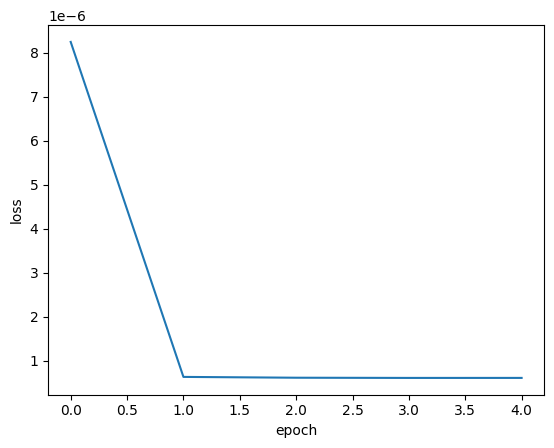

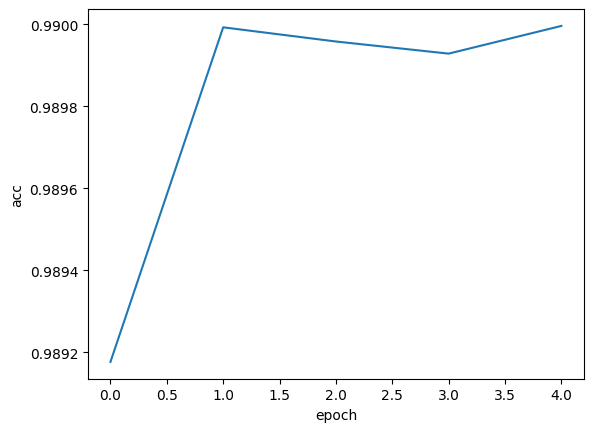

In [7]:
import matplotlib.pyplot as plt

plt.plot(tr_loss_list)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.plot(tr_acc_list)
plt.xlabel("epoch")
plt.ylabel("acc")
plt.show()

In [ ]:
def aggregate_prediction(pred):
    # may be usefull for simplified segmentation
    whole_tumor = (pred > 0)
    tumor_core = np.isin(pred, [1, 3])
    enhancing = (pred == 3)
    return whole_tumor, tumor_core, enhancing
